In [2]:
pip install kagglehub

In [3]:
pip install tensorflow

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samuelcortinhas/apples-or-tomatoes-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'apples-or-tomatoes-image-classification' dataset.
Path to dataset files: /kaggle/input/apples-or-tomatoes-image-classification


In [5]:
import os
import tensorflow as tf
DATASET_DIR = path
IMAGE_SIZE = (100,100)
BATCH_SIZE = 32
SEED = 123
LABEL_MODE_BINARY = "binary"
train_dir = os.path.join(DATASET_DIR,"train")
test_dir = os.path.join(DATASET_DIR,"test")

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = LABEL_MODE_BINARY,
    seed = SEED,
    shuffle = True
)

Found 294 files belonging to 2 classes.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = LABEL_MODE_BINARY,
    seed = 123,
    shuffle = False
)

Found 97 files belonging to 2 classes.


In [8]:
print(len(train_ds))
print(len(test_ds))

10
4


In [9]:
classes = train_ds.class_names
print("class names:",classes)

class names: ['apples', 'tomatoes']


In [10]:
1

1

In [11]:
def normlization(image,lable):
    image = tf.cast(image/255. ,tf.float32)
    return image, lable

In [12]:
train_ds = train_ds.map(normlization)
test_ds = test_ds.map(normlization)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D,MaxPooling2D,Flatten

In [14]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3),padding="valid",activation="relu", input_shape = (100,100,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Conv2D(64,kernel_size=(3,3),padding = "valid",activation= "relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Conv2D(128,kernel_size=(3,3),padding = "valid",activation= "relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(1, activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,097 (6.64 MB)

 Trainable params: 1,740,097 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer="adam", loss="binary_crossentropy",metrics=["accuracy"])

In [17]:
history = model.fit(train_ds,validation_data=(test_ds),epochs=30)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 382ms/step - accuracy: 0.4932 - loss: 0.7444 - val_accuracy: 0.5670 - val_loss: 0.6865
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6054 - loss: 0.6707 - val_accuracy: 0.5567 - val_loss: 0.7094
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5578 - loss: 0.6780 - val_accuracy: 0.6186 - val_loss: 0.6657
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6565 - loss: 0.6552 - val_accuracy: 0.6598 - val_loss: 0.6215
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6531 - loss: 0.6155 - val_accuracy: 0.6598 - val_loss: 0.6103
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6939 - loss: 0.5719 - val_accuracy: 0.6082 - val_loss: 0.6500
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6837 - loss: 0.6040 - val_accuracy: 0.6804 - val_loss: 0.6115
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7279 - loss: 0.5536 - val_accuracy: 0.6907 - 

In [18]:
model.save("AppleTomato.h5")

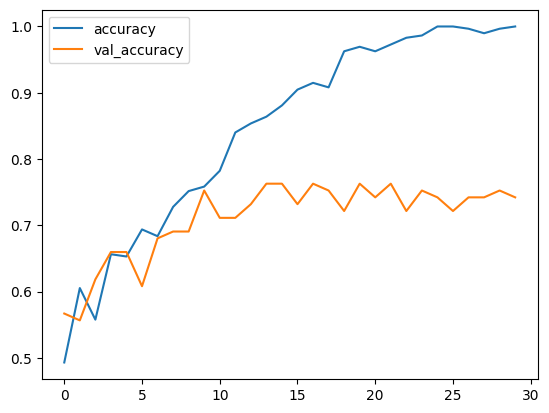

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()

In [20]:
pip install opencv-python

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
Raw Output: [[0.2329187]]


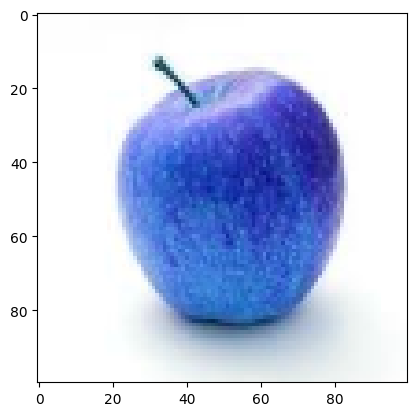

Prediction: Apple


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"apple.jpg")

# ✅ FIX: check if image loaded
if img is None:
    print("Error: Image not found. Check file path.")
else:
    # Resize to model input size
    img = cv2.resize(img, (100, 100))

    # Normalize (VERY IMPORTANT)
    img = img / 255.0

    # Reshape
    img = img.reshape(1, 100, 100, 3)

    # Prediction
    result = model.predict(img)

    print("Raw Output:", result)

    plt.imshow(img[0])
    plt.show()

    # Convert to class
    if result[0][0] > 0.5:
        print("Prediction: Tomato")
    else:
        print("Prediction: Apple")

In [25]:
import cv2
test_img1 = cv2.imread(r"apple.jpg")

In [26]:
test_img1 = cv2.resize(test_img1,(256,256))

In [27]:
test_img1_resized = None

# ✅ FIX: check before resize
if test_img1 is None:
    print("Error: Image not loaded. Check path.")
else:
    test_img1_resized = cv2.resize(test_img1, IMAGE_SIZE)
    test_input1 = test_img1_resized.reshape(1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
[[0.]]


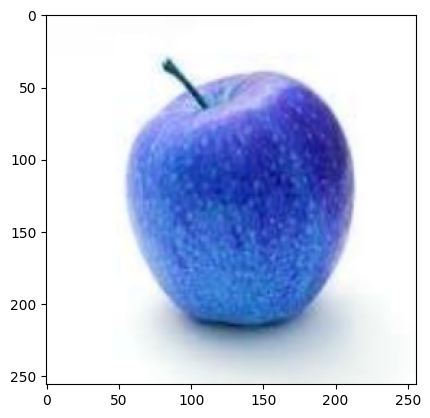

In [28]:
result = model.predict(test_input1)
print(result)
plt.imshow(test_img1)